In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
def tabelaFrequencia(freqAbSimpl, nomes):
    nomes.append('Total')
    freqAbSimpl = np.append(freqAbSimpl, sum(freqAbSimpl))
    freqRelSimpl = np.array([round(i/freqAbSimpl[-1], 2) for i in freqAbSimpl])
    freqAbAcum = []
    conta = 0
    for i in freqAbSimpl[:-1]:
        conta += i
        freqAbAcum.append(conta)
    freqAbAcum.append(np.nan)
    freqRelAcum = np.array([round(i/freqAbAcum[-2], 2) for i in freqAbAcum])
    columns=['Freq Absol Simp','Freq Relat Simp','Freq Absol Acum','Freq Relat Acum']
    df_ordinal = pd.DataFrame(columns=columns, index=nomes)
    df_ordinal[df_ordinal.columns[0]] = freqAbSimpl
    df_ordinal[df_ordinal.columns[1]] = freqRelSimpl
    df_ordinal[df_ordinal.columns[2]] = freqAbAcum
    df_ordinal[df_ordinal.columns[3]] = freqRelAcum
    return df_ordinal


In [38]:
def gera_numeros(num):
    return [str(round(np.random.rand() * 10, 2)) + '%' for _ in range(num)]

In [43]:
nomes = gera_numeros(20)
freqAbSimpl = np.random.randint(0, 1_000, 20)
df_continua = tabelaFrequencia(freqAbSimpl, nomes)
df_continua.head()

,Freq Absol Simp,Freq Relat Simp,Freq Absol Acum,Freq Relat Acum
0.52%,419,0.04,419.0,0.04
5.48%,289,0.03,708.0,0.07
3.65%,832,0.08,1540.0,0.16
6.25%,515,0.05,2055.0,0.21
4.25%,96,0.01,2151.0,0.22


<AxesSubplot:>

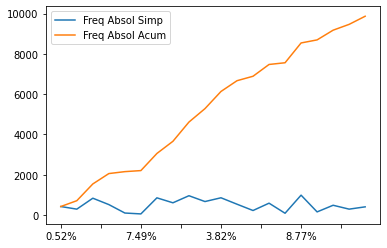

In [49]:
df_continua[df_continua.columns[[0,2]]].dropna().plot()

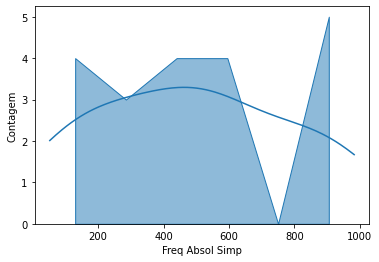

In [54]:
sns.histplot(
    x=df_continua.columns[0],
    kde=True,
    element='poly',
    data=df_continua.iloc[:-1]
)
plt.ylabel('Contagem')
plt.show()